# Backlight Halo Clustering Large-Scale Diagnostic

This notebook isolates the large-scale halo clustering comparison behind the pasted-map `gg`, `gy`, and `gtau` validation.  The goal is to check whether the low-ell deficit is already present in the halo catalog, before HOD sampling or gas-profile pasting enters.

The notebook compares the measured full-sky halo overdensity `C_ell` against Limber predictions using:

- the GODMAX/JAX-cosmo linear power used by the local analytic code,
- the same halo mass selection as the catalog, `M200c > 1e13`,
- the realized catalog `dN/dz`,
- HMF-weighted and actual catalog-mass-weighted effective halo bias,
- optional PyCCL public-code `angular_cl`, if `pyccl` is installed.

In [3]:
import json
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np

NOTEBOOK_DIR = pathlib.Path.cwd()
if NOTEBOOK_DIR.name != "SBI_validate":
    NOTEBOOK_DIR = pathlib.Path("/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate")
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import halo_clustering_diagnostic as hcd

plt.rcParams.update({"font.size": 12})

## Run Or Load Diagnostic

The helper module saves all intermediate arrays under `outputs/halo_clustering_large_scale_diagnostic.npz` so this notebook can be rerun quickly after the first pass.

In [4]:
output_path = hcd.DEFAULT_OUTPUT
if not output_path.exists():
    hcd.run_diagnostic(output_path=output_path)

diag = hcd.load_diagnostic(output_path)
arr = diag["arrays"]
meta = diag["metadata"]

print(json.dumps(meta, indent=2, sort_keys=True))

{
  "catalog_count": 4813871,
  "halo_catalog": "/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/backlight/halo_catalog_Mlim_1e13_zlim_0.4_0.6.h5",
  "lmax": 768,
  "mass_max": 1589715572621312.0,
  "mass_min": 10001098735616.0,
  "nside": 256,
  "pyccl_status": "pyccl angular_cl completed"
}


## Mass Selection And Effective Bias

If the large-scale issue were caused by inconsistent halo mass selection, the HMF-weighted and catalog-mass-weighted bias curves would differ appreciably.  They do not.

In [6]:
lo = arr["mass_summary_log10m_lo"]
hi = arr["mass_summary_log10m_hi"]
count = arr["mass_summary_catalog_count"].astype(int)
abund = arr["mass_summary_abundance_ratio_median"]
abund_p16 = arr["mass_summary_abundance_ratio_p16"]
abund_p84 = arr["mass_summary_abundance_ratio_p84"]
b_hmf = arr["mass_summary_bias_hmf_mean"]
b_cat = arr["mass_summary_bias_catalog_mean"]

print("log10M bin        Ncat       catalog/HMF        b_HMF     b_catalog")
for vals in zip(lo, hi, count, abund, abund_p16, abund_p84, b_hmf, b_cat):
    l, h, n, a, a16, a84, bh, bc = vals
    print(f"{l:5.2f}-{h:5.2f}  {n:9d}   {a:6.3f} [{a16:6.3f},{a84:6.3f}]   {bh:6.3f}   {bc:6.3f}")

z_grid = arr["bias_z_grid"]
b_gridmax = arr["bias_hmf_gridmax"]
b_catmax = arr["bias_hmf_catalog_max"]
b_catalog_for = arr["catalog_bias_for"]
z_for = arr["z_for"]

print("\nIntegrated b_eff checks:")
for z0 in [0.4, 0.5, 0.6]:
    print(
        f"z={z0:.1f}: "
        f"HMF gridmax={np.interp(z0, z_grid, b_gridmax):.4f}, "
        f"HMF catmax={np.interp(z0, z_grid, b_catmax):.4f}, "
        f"catalog weighted={np.interp(z0, z_for, b_catalog_for):.4f}"
    )

log10M bin        Ncat       catalog/HMF        b_HMF     b_catalog
13.00-13.25    2476798    1.518 [ 1.496, 1.531]    1.629    1.660
13.25-13.50    1289203    1.604 [ 1.563, 1.616]    1.929    1.945
13.50-13.75     628234    1.690 [ 1.659, 1.715]    2.341    2.327
13.75-14.00     275822    2.429 [ 2.353, 2.447]    2.843    2.841
14.00-14.25     104889    1.468 [ 1.431, 1.478]    3.493    3.547
14.25-14.50      30988    1.470 [ 1.385, 1.481]    4.557    4.533
14.50-15.00       7871    1.400 [ 1.378, 1.417]    6.419    6.169
15.00-15.75         66    0.773 [ 0.491, 0.954]   11.149   10.950

Integrated b_eff checks:
z=0.4: HMF gridmax=1.8319, HMF catmax=1.8318, catalog weighted=1.8270
z=0.5: HMF gridmax=1.9502, HMF catmax=1.9502, catalog weighted=1.9491
z=0.6: HMF gridmax=2.0783, HMF catmax=2.0783, catalog weighted=2.0690


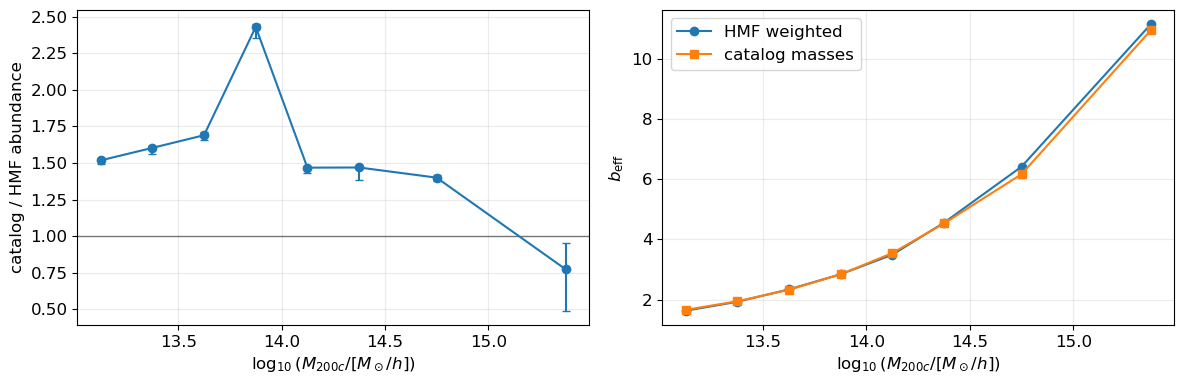

In [7]:
mass_centers = 0.5 * (lo + hi)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].errorbar(
    mass_centers,
    abund,
    yerr=[abund - abund_p16, abund_p84 - abund],
    marker="o",
    capsize=3,
)
axes[0].axhline(1.0, color="k", lw=1, alpha=0.5)
axes[0].set_xlabel(r"$\log_{10}(M_{200c}/[M_\odot/h])$")
axes[0].set_ylabel("catalog / HMF abundance")
axes[0].grid(True, alpha=0.25)

axes[1].plot(mass_centers, b_hmf, marker="o", label="HMF weighted")
axes[1].plot(mass_centers, b_cat, marker="s", label="catalog masses")
axes[1].set_xlabel(r"$\log_{10}(M_{200c}/[M_\odot/h])$")
axes[1].set_ylabel(r"$b_\mathrm{eff}$")
axes[1].grid(True, alpha=0.25)
axes[1].legend()

fig.tight_layout()

## Halo Angular Power

The map curve below is the measured halo overdensity auto-spectrum from the Backlight halo catalog, with Poisson shot noise subtracted.  The theory curves use the same realized catalog redshift window and matched mass cuts.

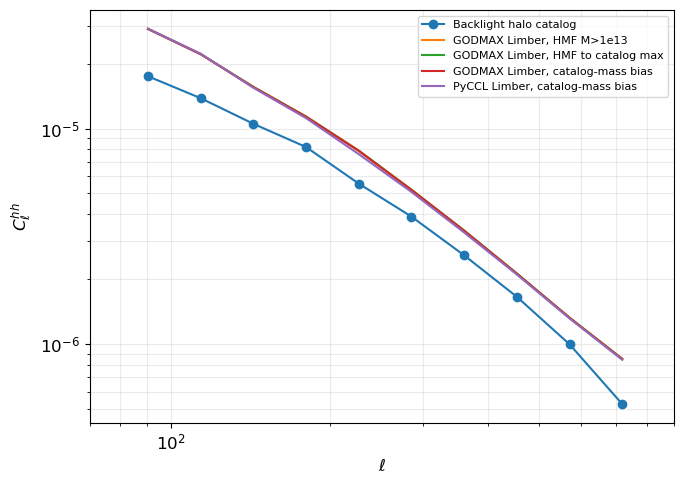

In [8]:
ell = arr["ell"]
cl_map = arr["halo_cl_signal_binned"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(ell, cl_map, marker="o", lw=1.5, label="Backlight halo catalog")
for key, label in [
    ("theory_hmf_gridmax_binned", "GODMAX Limber, HMF M>1e13"),
    ("theory_hmf_catalog_max_binned", "GODMAX Limber, HMF to catalog max"),
    ("theory_catalog_mass_weighted_binned", "GODMAX Limber, catalog-mass bias"),
    ("theory_pyccl_catalog_mass_weighted_binned", "PyCCL Limber, catalog-mass bias"),
    ("theory_pyccl_nonlimber_catalog_mass_weighted_binned", "PyCCL non-Limber FKEM, catalog-mass bias"),
]:
    if key in arr:
        ax.loglog(ell, arr[key], lw=1.5, label=label)
ax.set_xlim(70, 900)
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$C_\ell^{hh}$")
ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()

HMF M>1e13               median ratio ell<=300 = 0.688
HMF to catalog max       median ratio ell<=300 = 0.688
catalog-mass bias        median ratio ell<=300 = 0.690
PyCCL catalog-mass bias  median ratio ell<=300 = 0.705


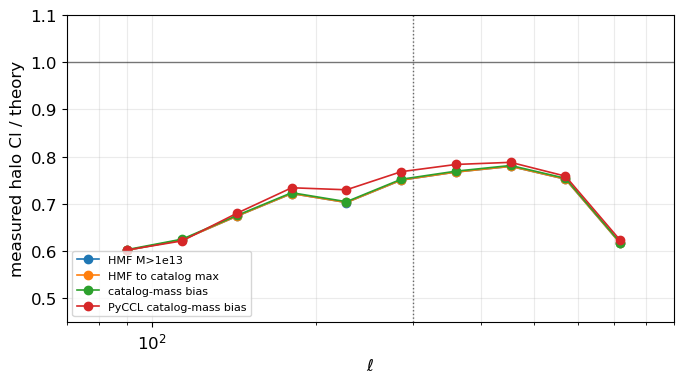

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ratio_keys = [
    ("ratio_hmf_gridmax_binned", "HMF M>1e13"),
    ("ratio_hmf_catalog_max_binned", "HMF to catalog max"),
    ("ratio_catalog_mass_weighted_binned", "catalog-mass bias"),
    ("ratio_pyccl_catalog_mass_weighted_binned", "PyCCL catalog-mass bias"),
    ("ratio_pyccl_nonlimber_catalog_mass_weighted_binned", "PyCCL non-Limber FKEM"),
]
for key, label in ratio_keys:
    if key in arr:
        ratio = arr[key]
        ax.semilogx(ell, ratio, marker="o", lw=1.2, label=label)
        print(f"{label:24s} median ratio ell<=300 = {np.nanmedian(ratio[ell <= 300]):.3f}")

ax.axhline(1.0, color="k", lw=1, alpha=0.5)
ax.axvline(300.0, color="0.4", ls=":", lw=1)
ax.set_xlim(70, 900)
ax.set_ylim(0.45, 1.1)
ax.set_xlabel(r"$\ell$")
ax.set_ylabel("measured halo Cl / theory")
ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()

## PyCCL Public-Code Cross-Check

The helper module attempts to run PyCCL if it is installed.  In the current environment this may be skipped, but the code path is in `halo_clustering_diagnostic.py::pyccl_limber_halo_cls` and will populate `theory_pyccl_catalog_mass_weighted*` arrays when available.

pyccl angular_cl completed


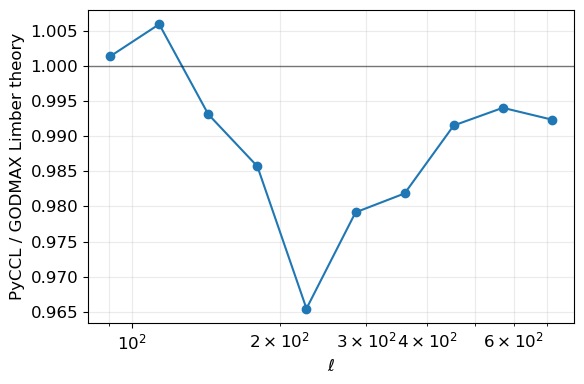

In [10]:
print("PyCCL Limber:", meta.get("pyccl_status"))
print("PyCCL non-Limber:", meta.get("pyccl_nonlimber_status"))
if "theory_pyccl_limber_bincenter_catalog_mass_weighted_binned" in arr and "theory_pyccl_nonlimber_catalog_mass_weighted_binned" in arr:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.semilogx(
        ell,
        arr["theory_pyccl_nonlimber_catalog_mass_weighted_binned"] / arr["theory_pyccl_limber_bincenter_catalog_mass_weighted_binned"],
        marker="s",
        label="non-Limber / Limber",
    )
    ax.semilogx(
        ell,
        arr["theory_pyccl_catalog_mass_weighted_binned"] / arr["theory_catalog_mass_weighted_binned"],
        marker="o",
        label="PyCCL Limber / GODMAX Limber",
    )
    ax.axhline(1.0, color="k", lw=1, alpha=0.5)
    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel("theory ratio")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend()
    fig.tight_layout()
else:
    print("PyCCL arrays are not present. Install pyccl in this kernel and rerun hcd.run_diagnostic() to add the public-code curve.")

## Interpretation

The low-ell deficit remains when the analytic prediction uses the same `M > 1e13` selection, the catalog maximum mass, the realized catalog redshift window, and the catalog-mass-weighted effective halo bias.  This isolates the issue to the Backlight halo catalog's measured large-scale angular clustering relative to the ensemble Limber prediction, rather than to the pasted y/tau profile normalization or to mismatched halo mass cuts.

The catalog/HMF abundance ratio is visibly mass dependent, but the effective bias barely changes because `b_eff` is a ratio of HMF-weighted integrals.  A broad abundance rescaling cancels, and the residual mass-dependent shape changes are not large enough to produce the observed 20-30 percent low-ell Cl suppression.